# DATA 620 Final Project
## NBA Trade Network and Public Sentiment Analysis

**Course:** DATA 620 Web Analytics
**Instructor:** Professor Alain Ledon

## Group Members
- Crystal Quezada — Data Sourcing and Feature Engineering
- Nana Kwasi Danquah — Network Construction and Topological Metrics
- Muhammad Suffyan Khan — Natural Language Processing and Thematic Text Analysis

## Video Presentation
[Video linked here](https://www.youtube.com/watch?v=jLMz6QdbxXk)

## Project Purpose
This project examines the NBA trade ecosystem during the **2025-26 season and the 2026 offseason**, with a documented data collection **cutoff date of July 10, 2026**. A directed network represents completed player movements, with teams serving as nodes and each movement acting as a directed edge connecting the sending and receiving teams. Following that, we examine selected sports-media narratives and fan-survey reports surrounding four major trades, comparing them with the teams and
transactions that the network identifies as structurally significant.

## Research Questions
1. Which NBA teams are the most central in the 2025–26 season and 2026 offseason trade network based on in-degree, out-degree, weighted in-degree, weighted out-degree, and betweenness centrality?
2. How do transaction volume and player salary movement relate to a team's structural position within the trade network?
3. What sentiments and recurring themes appear in public commentary and sports coverage surrounding selected major NBA trades?
4. How do these public narratives compare with the teams and transactions identified as important through the network analysis?


## Data and Methods Notes

**Trade data.** The transaction log (`nba_trades_2025_26.csv`) was compiled
using the official NBA.com trade trackers for the 2025–2026 season and the
2026 offseason, together with team releases linked from those trackers. The
dataset contains 37 officially completed trades and 109 movement records
through the documented cutoff date of July 10, 2026. Multi-team trades are
decomposed into directed movement records that retain a shared `trade_id`.
One draft-rights movement is retained in the transaction log but excluded from
the core player-movement network.

**Salary data.** The `salary_est_musd` field contains approximate salary values,
in millions of dollars, associated with each trade season. The completed
dataset contains no missing or negative salary values. The figures include
publicly reported contract amounts, contract-schedule estimates, rookie-scale
estimates, minimum-contract estimates, and other team-generated approximations
rather than consistently audited cap hits. Player-movement counts are therefore
used as the primary network weights, while salary-weighted results are treated
as supplemental indicators.

**Text corpus.** The raw `corpus_major_trades.csv` file contains 12 group-written
summaries of publicly available sports articles and fan-survey reports. One
syndicated duplicate, `D12`, is excluded during analysis, leaving 11 documents
covering the James Harden, Anthony Davis, Trae Young, and Deandre Ayton trades.
The original outlet, publication date, and URL are retained for every document.
Sentiment and thematic findings are evaluated at the document level and checked
through manual interpretation.

**Tools.** The analysis was conducted in Python using `pandas`, `NetworkX`,
`Matplotlib`, `SciPy`, `vaderSentiment`, and `scikit-learn`. The principal data
and software references are listed at the end of the notebook.

In [ ]:
# Environment setup — installs the one dependency not bundled with Anaconda/Colab.
# Safe to re-run; does nothing if already installed.
%pip install -q vaderSentiment

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

print('pandas', pd.__version__, '| networkx', nx.__version__)

pandas 1.3.5 | networkx 2.6.3


---
# Part 1 — Transaction Log: Loading, Cleaning and Structure
*(Component lead: Crystal Quezada)*

We load the compiled transaction log, standardize team identifiers, look for anomalies, and summarize the data.

In [ ]:
DATA_URL = (
    "https://raw.githubusercontent.com/suffyankhan77/"
    "DATA620-Web-Analytics/refs/heads/main/projects/final_project/"
)

trades = pd.read_csv(
    DATA_URL + "nba_trades_2025_26.csv",
    parse_dates=["trade_date"]
)

TEAM_NAMES = {
 'ATL':'Atlanta Hawks','BOS':'Boston Celtics','BKN':'Brooklyn Nets','CHA':'Charlotte Hornets',
 'CHI':'Chicago Bulls','CLE':'Cleveland Cavaliers','DAL':'Dallas Mavericks','DEN':'Denver Nuggets',
 'DET':'Detroit Pistons','GSW':'Golden State Warriors','HOU':'Houston Rockets','IND':'Indiana Pacers',
 'LAC':'LA Clippers','LAL':'Los Angeles Lakers','MEM':'Memphis Grizzlies','MIA':'Miami Heat',
 'MIL':'Milwaukee Bucks','MIN':'Minnesota Timberwolves','NOP':'New Orleans Pelicans','NYK':'New York Knicks',
 'OKC':'Oklahoma City Thunder','ORL':'Orlando Magic','PHI':'Philadelphia 76ers','PHX':'Phoenix Suns',
 'POR':'Portland Trail Blazers','SAC':'Sacramento Kings','SAS':'San Antonio Spurs','TOR':'Toronto Raptors',
 'UTA':'Utah Jazz','WAS':'Washington Wizards'}

# --- Cleaning and validation checks ---
assert trades["from_team"].isin(TEAM_NAMES).all(), \
    "Unknown origin team code"
assert trades["to_team"].isin(TEAM_NAMES).all(), \
    "Unknown destination team code"
assert (trades["from_team"] != trades["to_team"]).all(), \
    "Self-loop found"

# Missing salaries are allowed temporarily, but non-missing salaries cannot be negative.
assert trades["salary_est_musd"].dropna().ge(0).all(), \
    "Negative salary found among non-missing values"

dupes = trades.duplicated(
    subset=["trade_id", "player", "from_team", "to_team"]
).sum()

negative_salary_count = (
    trades["salary_est_musd"].dropna().lt(0).sum()
)

missing_salary_count = trades["salary_est_musd"].isna().sum()

print("Duplicate movement rows:", dupes)
print("Negative salary values:", negative_salary_count)
print("Missing salary values:", missing_salary_count)

print(
    f"{len(trades)} movement rows across "
    f"{trades['trade_id'].nunique()} official trades"
)

print(
    f"Date range: {trades['trade_date'].min().date()} to "
    f"{trades['trade_date'].max().date()} "
    "(cutoff 2026-07-10)"
)

trades.head(8)

Duplicate movement rows: 0
Negative salary values: 0
Missing salary values: 0
109 movement rows across 37 official trades
Date range: 2026-01-09 to 2026-07-10 (cutoff 2026-07-10)


,trade_id,trade_date,season_phase,player,from_team,to_team,salary_est_musd,movement_type,salary_verified,official_source_url
0,T01,2026-01-09,2025-26 season,Trae Young,ATL,WAS,46.0,player,no (estimate — verify vs Spotrac),https://www.nba.com/news/2025-26-nba-trade-tra...
1,T01,2026-01-09,2025-26 season,CJ McCollum,WAS,ATL,30.7,player,no (estimate — verify vs Spotrac),https://www.nba.com/news/2025-26-nba-trade-tra...
2,T01,2026-01-09,2025-26 season,Corey Kispert,WAS,ATL,13.9,player,no (estimate — verify vs Spotrac),https://www.nba.com/news/2025-26-nba-trade-tra...
3,T02,2026-02-01,2025-26 season,Vit Krejci,ATL,POR,2.2,player,no (estimate — verify vs Spotrac),https://www.nba.com/news/2025-26-nba-trade-tra...
4,T02,2026-02-01,2025-26 season,Duop Reath,POR,ATL,2.2,player,no (estimate — verify vs Spotrac),https://www.nba.com/news/2025-26-nba-trade-tra...
5,T03,2026-02-01,2025-26 season,Emanuel Miller,CHI,CLE,1.9,player,no (estimate — verify vs Spotrac),https://www.nba.com/news/2025-26-nba-trade-tra...
6,T03,2026-02-01,2025-26 season,De'Andre Hunter,CLE,SAC,23.3,player,no (estimate — verify vs Spotrac),https://www.nba.com/news/2025-26-nba-trade-tra...
7,T03,2026-02-01,2025-26 season,Dario Saric,SAC,CHI,5.4,player,no (estimate — verify vs Spotrac),https://www.nba.com/news/2025-26-nba-trade-tra...


**Data Validation.** Before constructing the network, the transaction data were
checked for standardized team abbreviations, duplicate player movements,
self-loops, invalid team codes, missing salaries, and negative salary values.
No duplicate movements, self-loops, unknown teams, missing salaries, or negative
salary values were found. Each row represents one movement from an officially
completed NBA trade, with the single draft-rights movement clearly identified
and excluded from the core player network.

In [ ]:
# Dataset structure and summary
print(trades["season_phase"].value_counts().to_string(), "\n")
print(trades["movement_type"].value_counts().to_string(), "\n")

# Movements per trade
trade_sizes = (
    trades.groupby("trade_id")
    .size()
    .sort_values(ascending=False)
)

print("Movements per trade (top 6):")
print(trade_sizes.head(6).to_string())
print()

# Summary statistics
total_trades = trades["trade_id"].nunique()

deadline_date = pd.Timestamp("2026-02-05")
deadline_trade_count = trades.loc[
    trades["trade_date"].eq(deadline_date),
    "trade_id"
].nunique()

largest_trade_size = trade_sizes.iloc[0]

largest_trade_ids = trade_sizes[
    trade_sizes.eq(largest_trade_size)
].index.tolist()

# Players appearing in more than one trade
player_trade_counts = (
    trades.loc[trades["movement_type"].eq("player")]
    .groupby("player")["trade_id"]
    .nunique()
    .sort_values(ascending=False)
)

repeat_movers = player_trade_counts[
    player_trade_counts.gt(1)
]

print("Total unique trades:", total_trades)
print("Trades on February 5, 2026:", deadline_trade_count)
print("Largest trade ID(s):", largest_trade_ids)
print("Player movements in largest trade:", largest_trade_size)
print("Players appearing in multiple trades:", len(repeat_movers))
print()

print("Repeat movers:")
print(repeat_movers.to_string())

2025-26 season    75
2026 offseason    34 

player          108
draft_rights      1 

Movements per trade (top 6):
trade_id
T36    10
T10     9
T04     8
T37     6
T31     6
T03     5

Total unique trades: 37
Trades on February 5, 2026: 17
Largest trade ID(s): ['T36']
Player movements in largest trade: 10
Players appearing in multiple trades: 10

Repeat movers:
player
Ousmane Dieng       3
AJ Johnson          2
D'Angelo Russell    2
Tyus Jones          2
Mike Conley         2
Khris Middleton     2
Jaden Hardy         2
Dario Saric         2
Dalen Terry         2
Jock Landale        2


**Observations.** The updated dataset contains 37 officially completed trades and 109 total movement records, including 108 roster-player movements and one draft-rights movement. The February 5, 2026 trade deadline remains the busiest date in the study window, with 17 completed trades. The largest transaction is the six-team offseason trade identified as T36, which contains 10 player movements.

Ten players appear in more than one trade during the study period. Ousmane Dieng appears in three separate trades, while AJ Johnson, D'Angelo Russell, Tyus Jones, Mike Conley, Khris Middleton, Jaden Hardy, Dario Saric, Dalen Terry, and Jock
Landale each appear in two. This supports the decision to preserve one row per player movement while linking related movements through a shared `trade_id`.

**Salary Data Quality.** The transaction dataset includes approximate salary values associated with each trade season used for supplemental weighted-network analysis. Missing values associated with the expanded 2026 offseason dataset were completed using publicly reported contract figures, rookie-scale estimates, and minimum-contract estimates. Values were rounded to the nearest $0.1 million for consistency.

Because some salary figures remain estimates rather than audited cap hits, player-count measures are treated as the primary network results. Salary-weighted measures are presented as supplemental indicators and interpreted with appropriate caution.

---
# Part 2 — Directed Trade Network and Topological Metrics
*(Component lead: Nana Kwasi Danquah)*

Teams are nodes, and each player movement generates a directed edge **from the sending team to the receiving team**. We first create a 'MultiDiGraph' that preserves each movement (with edge attributes 'trade_id', player, and salary), then aggregate parallel edges into a weighted 'DiGraph' with two alternative edge weights: the **number of player movements** ('n_moves') and the **total salary value moved** ('salary').

In [ ]:
# Player movements only for the core network (The draft-rights row is excluded)
pm = trades.loc[
    trades["movement_type"].eq("player")
].copy()

# MultiDiGraph: every player movement is a separate directed edge.
MG = nx.MultiDiGraph()
# Include all 30 NBA teams, including teams with no completed trade.
MG.add_nodes_from(TEAM_NAMES.keys())
for _, row in pm.iterrows():
    MG.add_edge(
        row.from_team,
        row.to_team,
        trade_id=row.trade_id,
        player=row.player,
        salary=row.salary_est_musd,
        date=str(row.trade_date.date()),
    )
# Aggregate parallel movements between the same ordered team pair.
agg = (
    pm.groupby(["from_team", "to_team"])
    .agg(
        n_moves=("player", "size"),
        salary=("salary_est_musd", "sum"),
    )
    .reset_index()
)
G = nx.DiGraph()
# Preserve all 30 teams in the aggregated graph.
G.add_nodes_from(TEAM_NAMES.keys())
for _, row in agg.iterrows():
    G.add_edge(
        row.from_team,
        row.to_team,
        n_moves=int(row.n_moves),
        salary=float(row.salary),
    )
# Teams with no incoming or outgoing player movements.
inactive = sorted(
    node for node in G.nodes
    if G.degree(node) == 0
)
print(
    f"MultiDiGraph: {MG.number_of_nodes()} teams, "
    f"{MG.number_of_edges()} movement edges")
print(
    f"Aggregated DiGraph: {G.number_of_nodes()} teams, "
    f"{G.number_of_edges()} directed team-to-team links")
print(
    "Teams with no completed trade in the window:",
    inactive if inactive else "none",)

MultiDiGraph: 30 teams, 108 movement edges
Aggregated DiGraph: 30 teams, 76 directed team-to-team links
Teams with no completed trade in the window: ['SAS']


In [ ]:
# --- Centrality measures: Research Question 1 ---
cent = pd.DataFrame(index=sorted(G.nodes))
# Raw degree counts: number of distinct trade partners
cent["in_degree"] = pd.Series(
    dict(G.in_degree())
)
cent["out_degree"] = pd.Series(
    dict(G.out_degree())
)
# Normalized degree centralities
cent["in_degree_centrality"] = pd.Series(
    nx.in_degree_centrality(G)
)
cent["out_degree_centrality"] = pd.Series(
    nx.out_degree_centrality(G)
)
# Weighted degree measures
cent["w_in_moves"] = pd.Series(
    dict(G.in_degree(weight="n_moves"))
)
cent["w_out_moves"] = pd.Series(
    dict(G.out_degree(weight="n_moves"))
)
cent["w_in_salary"] = pd.Series(
    dict(G.in_degree(weight="salary"))
)
cent["w_out_salary"] = pd.Series(
    dict(G.out_degree(weight="salary"))
)
# Convert movement frequency into distance:
# heavily used trade channels are treated as shorter.
for source, destination, edge_data in G.edges(data=True):
    edge_data["dist"] = 1.0 / edge_data["n_moves"]

cent["betweenness"] = pd.Series(
    nx.betweenness_centrality(
        G,
        normalized=True,
    )
)
cent["betweenness_w"] = pd.Series(
    nx.betweenness_centrality(
        G,
        weight="dist",
        normalized=True,
    )
)
cent["total_moves"] = (
    cent["w_in_moves"]
    + cent["w_out_moves"]
)
cent["net_salary"] = (
    cent["w_in_salary"]
    - cent["w_out_salary"]
).round(1)

cent = cent.fillna(0).round(3)

centrality_display = (
    cent.sort_values(
        "total_moves",
        ascending=False,
    )
    [
        [
            "in_degree", "out_degree","in_degree_centrality","out_degree_centrality","w_in_moves","w_out_moves","total_moves",
            "betweenness","betweenness_w","w_in_salary","w_out_salary","net_salary",
        ]
    ]
    .head(12)
)

centrality_display

,in_degree,out_degree,in_degree_centrality,out_degree_centrality,w_in_moves,w_out_moves,total_moves,betweenness,betweenness_w,w_in_salary,w_out_salary,net_salary
CHI,8,7,0.276,0.241,11,11,22,0.474,0.489,123.8,96.2,27.6
MEM,6,3,0.207,0.103,10,6,16,0.051,0.102,94.7,111.1,-16.4
WAS,3,5,0.103,0.172,7,8,15,0.145,0.215,136.0,104.2,31.8
CHA,7,4,0.241,0.138,9,6,15,0.251,0.299,86.6,92.4,-5.8
MIL,4,3,0.138,0.103,7,6,13,0.097,0.097,72.7,97.6,-24.9
ATL,7,4,0.241,0.138,9,4,13,0.111,0.082,112.2,89.9,22.3
DAL,4,2,0.138,0.069,6,6,12,0.058,0.160,72.8,85.1,-12.3
UTA,2,3,0.069,0.103,5,6,11,0.035,0.018,61.4,68.2,-6.8
DET,4,4,0.138,0.138,6,4,10,0.119,0.124,59.8,45.2,14.6
MIN,2,3,0.069,0.103,4,5,9,0.013,0.021,65.7,78.0,-12.3


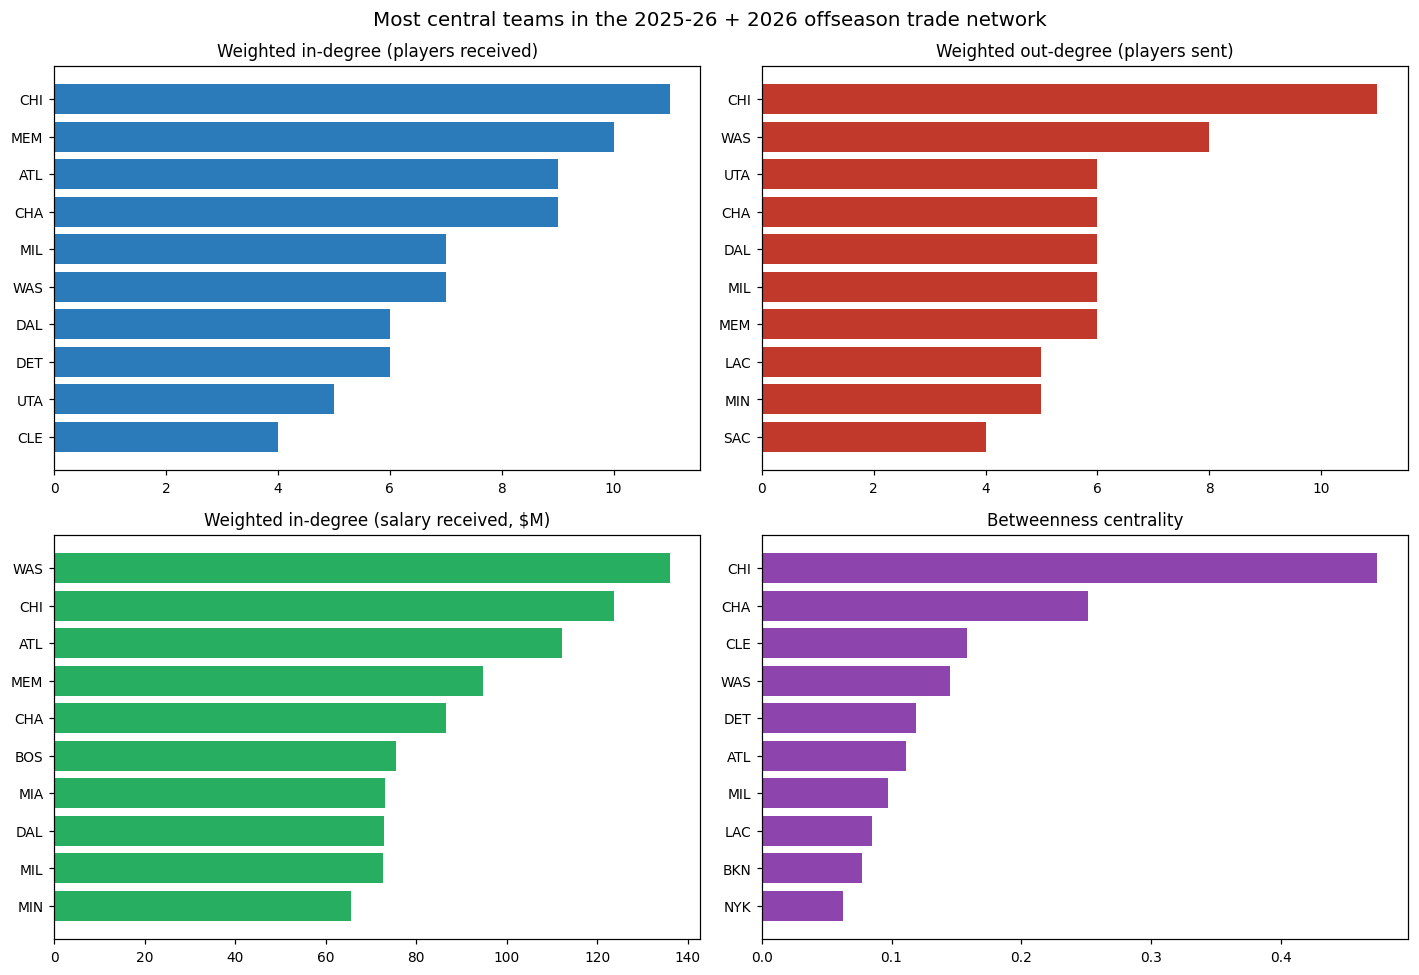

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
top = lambda col, n=10: cent[col].sort_values(ascending=False).head(n)

for ax, (col, title, color) in zip(axes.flat, [
        ('w_in_moves',  'Weighted in-degree (players received)',  '#2b7bba'),
        ('w_out_moves', 'Weighted out-degree (players sent)',      '#c0392b'),
        ('w_in_salary', 'Weighted in-degree (salary received, $M)','#27ae60'),
        ('betweenness', 'Betweenness centrality',                  '#8e44ad')]):
    s = top(col)
    ax.barh(s.index[::-1], s.values[::-1], color=color)
    ax.set_title(title, fontsize=11)
    ax.tick_params(labelsize=9)
fig.suptitle('Most central teams in the 2025-26 + 2026 offseason trade network', fontsize=13)
plt.tight_layout()
plt.show()

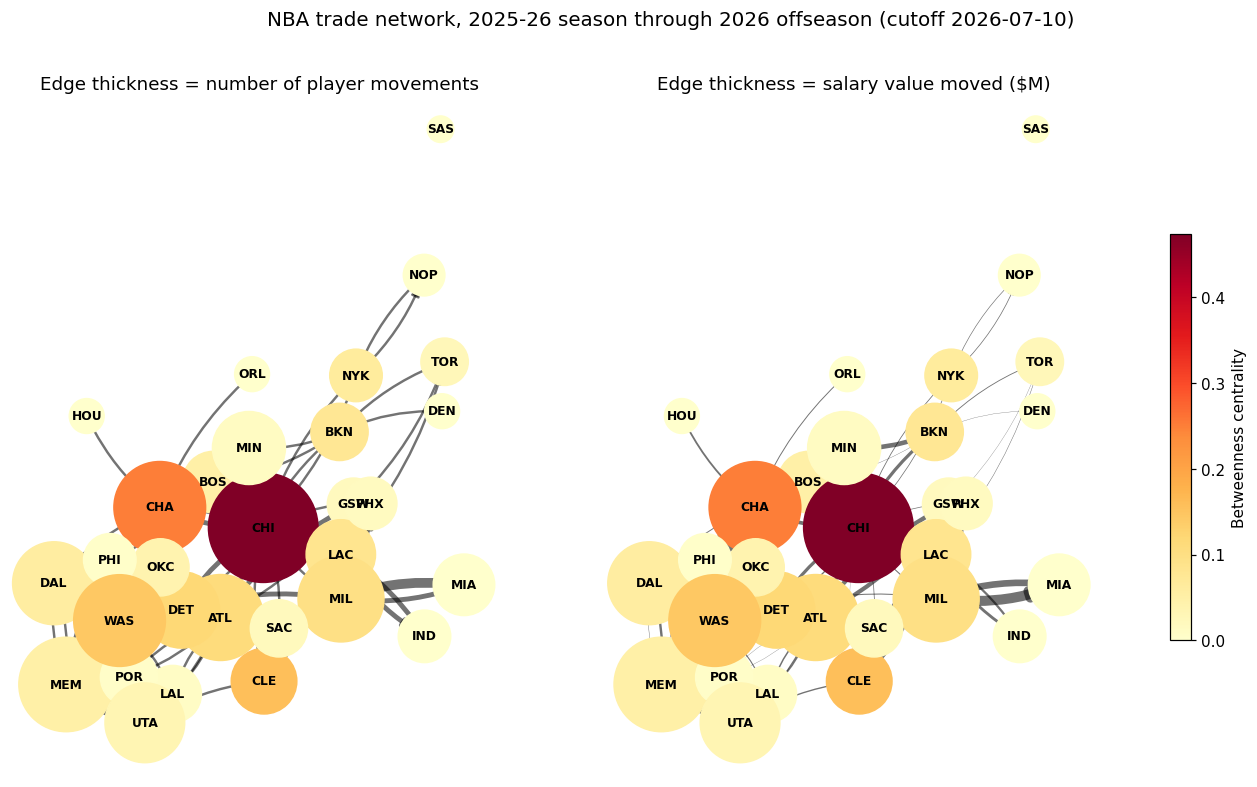

In [ ]:
# --- Network visualization with edge thickness by trade activity ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
pos = nx.spring_layout(G, k=1.4, seed=620, iterations=200)

node_size = [300 + 220*cent.loc[n,'total_moves'] for n in G.nodes]
node_col  = [cent.loc[n,'betweenness'] for n in G.nodes]

for ax, wkey, title, scale in [(axes[0],'n_moves','Edge thickness = number of player movements',1.6),
                               (axes[1],'salary','Edge thickness = salary value moved ($M)',0.09)]:
    widths = [scale*d[wkey] for _,_,d in G.edges(data=True)]
    nodes = nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_size,
                                   node_color=node_col, cmap='YlOrRd')
    nx.draw_networkx_edges(G, pos, ax=ax, width=widths, alpha=0.55,
                           arrowsize=11, connectionstyle='arc3,rad=0.12')
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_weight='bold')
    ax.set_title(title); ax.axis('off')
fig.colorbar(nodes, ax=axes, shrink=0.6, label='Betweenness centrality')
plt.suptitle('NBA trade network, 2025-26 season through 2026 offseason (cutoff 2026-07-10)', fontsize=13)
plt.show()

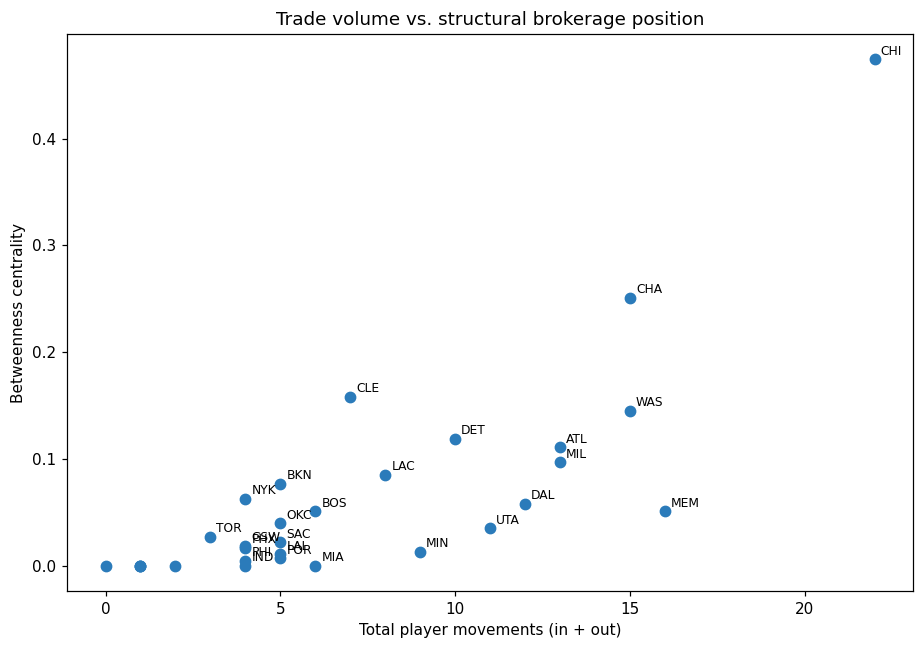

Spearman correlation, volume vs betweenness: rho=0.781, p=3.512e-07, n=30
Spearman correlation, salary throughput vs betweenness: rho=0.709, p=1.175e-05, n=30

Largest net salary importers ($M):
WAS    31.8
LAL    29.4
CHI    27.6
MIA    25.0
ATL    22.3

Largest net salary exporters ($M):
MIL   -24.9
LAC   -24.8
OKC   -21.2
MEM   -16.4
CLE   -15.2


In [ ]:
# --- RQ2: transaction volume and salary movement vs structural position ---
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.scatter(cent.total_moves, cent.betweenness, s=45, color='#2b7bba')
for t, r in cent.iterrows():
    if r.total_moves >= 4 or r.betweenness >= 0.02:
        ax.annotate(t, (r.total_moves, r.betweenness), fontsize=8,
                    xytext=(4, 3), textcoords='offset points')
ax.set_xlabel('Total player movements (in + out)')
ax.set_ylabel('Betweenness centrality')
ax.set_title('Trade volume vs. structural brokerage position')
plt.tight_layout(); plt.show()

from scipy.stats import spearmanr
# Total incoming and outgoing estimated salary movement
salary_throughput = (
    cent["w_in_salary"]
    + cent["w_out_salary"]
)
# Spearman rank correlations
corr_volume, p_volume = spearmanr(
    cent["total_moves"],
    cent["betweenness"],
)
corr_salary, p_salary = spearmanr(
    salary_throughput,
    cent["betweenness"],
)
print(
    "Spearman correlation, volume vs betweenness: "
    f"rho={corr_volume:.3f}, "
    f"p={p_volume:.4g}, "
    f"n={len(cent)}"
)
print(
    "Spearman correlation, salary throughput vs betweenness: "
    f"rho={corr_salary:.3f}, "
    f"p={p_salary:.4g}, "
    f"n={len(cent)}"
)
print("\nLargest net salary importers ($M):")
print(
    cent["net_salary"]
    .sort_values(ascending=False)
    .head(5)
    .to_string()
)
print("\nLargest net salary exporters ($M):")
print(
    cent["net_salary"]
    .sort_values()
    .head(5)
    .to_string()
)

### Network Findings: Research Questions 1 and 2

- **Chicago is the central hub of the expanded trade network.** The Bulls are
  involved in 22 player movements, consisting of 11 incoming and 11 outgoing
  movements. Chicago also has the highest unweighted betweenness centrality
  (`0.474`) and movement-weighted betweenness centrality (`0.489`). This means
  Chicago combines high transaction volume with the strongest brokerage
  position in the network.

- **Memphis, Charlotte, and Washington are also major trade participants.**
  Memphis records 16 total player movements, while Charlotte and Washington
  each record 15. Charlotte has the second-highest betweenness centrality,
  demonstrating that it connects important sections of the network in addition
  to handling a high volume of player movements.

- **Washington leads estimated incoming salary movement.** Washington receives
  approximately `$136.0 million` in salary value and has the largest positive
  net salary balance at approximately `$31.8 million`. Chicago and Atlanta also
  rank highly in estimated incoming salary. Because some salary figures are
  approximate, these financial results are treated as supplemental rather than
  the primary evidence of network importance.

- **Player volume is more closely associated with brokerage position than
  salary throughput.** The Spearman correlation between total player movements
  and betweenness centrality is strong and statistically significant
  (`ρ = 0.781`, `p < 0.001`, `n = 30`). The relationship between estimated
  salary throughput and betweenness centrality is also strong and statistically
  significant (`ρ = 0.709`, `p < 0.001`, `n = 30`). These results indicate that
  highly active teams generally occupy more important structural positions,
  although transaction volume and financial scale do not completely determine
  brokerage centrality.

- **The network measures capture different dimensions of trade activity.**
  Player-count weights identify teams that participate in many player
  movements, salary weights emphasize the financial scale of those movements,
  and betweenness centrality identifies teams that connect otherwise separated
  portions of the trade network. Chicago ranks highly across these dimensions,
  while teams such as Washington and Charlotte stand out for different reasons.

- **San Antonio is the only inactive team in the study window.** Because the
  Spurs have no completed player movement in the dataset, they have zero degree
  and betweenness centrality. They remain included in the graph so that the
  analysis represents all 30 NBA teams.

---
# Part 3 — Public Sentiment and Thematic Text Analysis
*(Component lead: Muhammad Suffyan Khan)*

We conduct an exploratory document-level analysis of selected media narratives
surrounding four major NBA trades. The corpus consists of group-written summaries
of publicly available sports articles and fan-survey reports, with the original
outlet, publication date, and URL retained for verification.

The pipeline includes text cleaning and tokenization, VADER sentiment scoring,
trade-level aggregation, TF-IDF keyword extraction, and rule-based tagging of
recurring themes identified in the proposal: rebuilding, championship
contention or win-now pressure, salary-cap pressure, and injury or durability.

Most documents are retrospective evaluations published weeks or months after
the corresponding trades rather than immediate reactions. Therefore, the
results describe sentiment and themes within this selected media corpus and
should not be interpreted as a representative measure of all NBA fan opinion.

In [ ]:
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer

# Load the curated text corpus from GitHub.
corpus_raw = pd.read_csv(
    DATA_URL + "corpus_major_trades.csv",
    parse_dates=["pub_date"],
)

# D12 is a Yahoo Sports syndication of the same Fear The Sword
# fan-survey story represented by D01. Exclude it to avoid
# counting the same underlying narrative twice.
excluded_doc_ids = ["D12"]

corpus = (
    corpus_raw.loc[
        ~corpus_raw["doc_id"].isin(excluded_doc_ids)
    ]
    .copy()
    .reset_index(drop=True)
)

# Attach each document to the date of its corresponding trade.
trade_dates = (
    trades.groupby("trade_id")["trade_date"]
    .min()
)

corpus["trade_date"] = (
    corpus["trade_id"]
    .map(trade_dates)
)

assert corpus["trade_date"].notna().all(), \
    "A corpus trade ID does not match the transaction dataset"

corpus["days_after_trade"] = (
    corpus["pub_date"] - corpus["trade_date"]
).dt.days


def clean_text(text):
    """Lowercase text and retain letters, numbers, spaces, and hyphens."""
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s\-]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


corpus["clean"] = corpus["text"].map(clean_text)
corpus["tokens"] = corpus["clean"].str.split()

# VADER document-level sentiment
sia = SentimentIntensityAnalyzer()

corpus["compound"] = corpus["text"].map(
    lambda text: sia.polarity_scores(text)["compound"]
)

# Standard VADER thresholds:
# compound <= -0.05 is negative,
# compound >= 0.05 is positive,
# values between the thresholds are neutral.
corpus["sent_label"] = np.select(
    [
        corpus["compound"].le(-0.05),
        corpus["compound"].ge(0.05),
    ],
    [
        "negative",
        "positive",
    ],
    default="neutral",
)

# Corpus audit
print("Raw documents:", len(corpus_raw))
print("Excluded syndicated duplicates:", len(excluded_doc_ids))
print("Documents analyzed:", len(corpus))
print("Trades covered:", sorted(corpus["trade_id"].unique()))
print(
    "Median document length:",
    int(corpus["tokens"].str.len().median()),
    "tokens",
)

timing_summary = (
    corpus.groupby(["trade_id", "trade_focus"])
    .agg(
        documents=("doc_id", "size"),
        earliest_days_after_trade=("days_after_trade", "min"),
        latest_days_after_trade=("days_after_trade", "max"),
        median_days_after_trade=("days_after_trade", "median"),
    )
    .reset_index()
)

print("\nPublication timing relative to each trade:")
print(timing_summary.to_string(index=False))

corpus[
    [
        "doc_id",
        "trade_focus",
        "outlet",
        "trade_date",
        "pub_date",
        "days_after_trade",
        "compound",
        "sent_label",
    ]
]

Raw documents: 12
Excluded syndicated duplicates: 1
Documents analyzed: 11
Trades covered: ['T01', 'T06', 'T10', 'T27']
Median document length: 50 tokens

Publication timing relative to each trade:
trade_id   trade_focus  documents  earliest_days_after_trade  latest_days_after_trade  median_days_after_trade
     T01    Trae Young          2                        172                      182                    177.0
     T06  James Harden          4                         28                      142                    109.0
     T10 Anthony Davis          4                        138                      154                    141.0
     T27 Deandre Ayton          1                          1                        1                      1.0


,doc_id,trade_focus,outlet,trade_date,pub_date,days_after_trade,compound,sent_label
0,D01,James Harden,Fear The Sword,2026-02-04,2026-06-26,142,-0.8834,negative
1,D02,James Harden,SI / Cavaliers On SI,2026-02-04,2026-03-04,28,0.8641,positive
2,D03,James Harden,King James Gospel,2026-02-04,2026-04-27,82,-0.9231,negative
3,D04,James Harden,Fear The Sword,2026-02-04,2026-06-20,136,0.5574,positive
4,D05,Anthony Davis,Bleacher Report,2026-02-05,2026-06-25,140,-0.4215,negative
5,D06,Anthony Davis,ESPN,2026-02-05,2026-07-09,154,0.5719,positive
6,D07,Anthony Davis,Yardbarker / EssentiallySports,2026-02-05,2026-06-23,138,-0.2500,negative
7,D08,Anthony Davis,Bullets Forever,2026-02-05,2026-06-27,142,-0.0258,neutral
8,D09,Trae Young,ESPN,2026-01-09,2026-07-10,182,0.6249,positive
9,D10,Trae Young,Bleacher Report,2026-01-09,2026-06-30,172,0.8588,positive


trade_id   trade_focus  docs  mean_compound  min_c  max_c
     T01    Trae Young     2          0.742  0.625  0.859
     T06  James Harden     4         -0.096 -0.923  0.864
     T10 Anthony Davis     4         -0.031 -0.422  0.572
     T27 Deandre Ayton     1          0.893  0.893  0.893


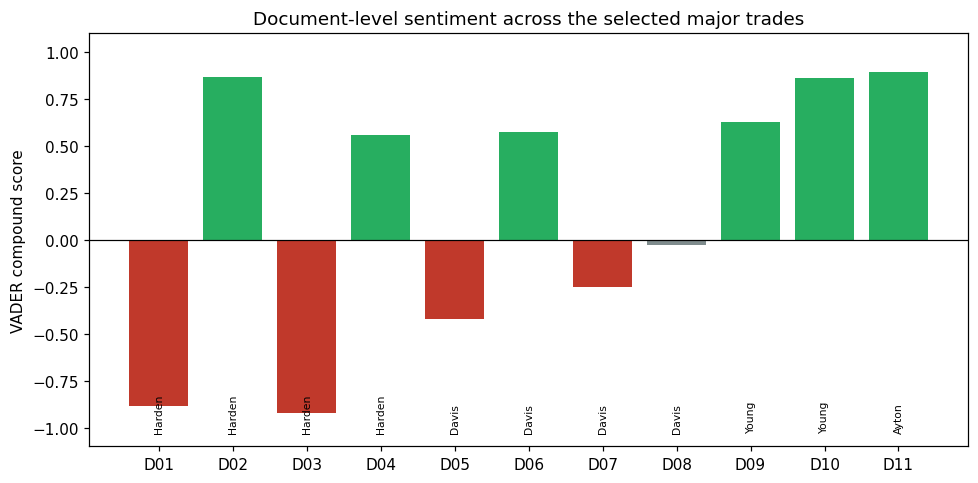

In [ ]:
# Confirm that the deduplicated corpus is being analyzed.
assert len(corpus) == 11, \
    f"Expected 11 documents, found {len(corpus)}"

assert "D12" not in set(corpus["doc_id"]), \
    "The syndicated duplicate D12 is still present"

# Sentiment aggregated by trade
by_trade = (
    corpus.groupby(["trade_id", "trade_focus"])
    .agg(
        docs=("doc_id", "size"),
        mean_compound=("compound", "mean"),
        min_c=("compound", "min"),
        max_c=("compound", "max"),
    )
    .round(3)
    .reset_index()
)

print(by_trade.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = corpus['compound'].map(lambda c: '#27ae60' if c > .05 else ('#c0392b' if c < -.05 else '#7f8c8d'))
ax.bar(corpus['doc_id'], corpus['compound'], color=colors)
ax.axhline(0, color='k', lw=.8)
ax.set_ylabel('VADER compound score')
ax.set_title('Document-level sentiment across the selected major trades')
for i, tf in enumerate(corpus['trade_focus']):
    ax.annotate(tf.split()[-1], (i, -1.02), fontsize=7, ha='center', rotation=90)
ax.set_ylim(-1.1, 1.1)
plt.tight_layout(); plt.show()

In [ ]:
# Confirm that the deduplicated corpus is used for thematic analysis.
assert len(corpus) == 11, \
    f"Expected 11 documents, found {len(corpus)}"

assert "D12" not in set(corpus["doc_id"]), \
    "D12 must remain excluded from thematic analysis"

# TF-IDF keywords per trade focus + rule-based theme tagging
THEMES = {
 'win-now / contention': ['win-now','championship','contend','contender','all in','gamble','playoff'],
 'rebuilding':           ['rebuild','young core','development','draft','future','flexibility'],
 'salary-cap pressure':  ['salary','cap','luxury tax','contract','extension','max','money'],
 'injury / durability':  ['injury','injured','health','durability','fracture','games played','sidelined'],
}
def tag_themes(text):
    t = text.lower()
    return [name for name, kws in THEMES.items() if any(k in t for k in kws)]
corpus['themes'] = corpus['text'].map(tag_themes)

theme_counts = pd.Series([th for lst in corpus.themes for th in lst]).value_counts()
print('Theme frequency across the corpus:')
print(theme_counts.to_string(), '\n')

for focus, grp in corpus.groupby('trade_focus'):
    tfidf = TfidfVectorizer(stop_words='english', ngram_range=(1,2), max_features=2000)
    X = tfidf.fit_transform(grp['clean'])
    scores = np.asarray(X.mean(axis=0)).ravel()
    terms = np.array(tfidf.get_feature_names_out())
    topk = terms[np.argsort(scores)[::-1][:8]]
    print(f'{focus:16s} -> ' + ', '.join(topk))

Theme frequency across the corpus:
rebuilding              6
win-now / contention    4
injury / durability     4
salary-cap pressure     4 

Anthony Davis    -> davis, trade, washington, young, million, salary, committed, possible
Deandre Ayton    -> young, center, young posted, deandre ayton, davis, davis core, deal, deal wizards
James Harden     -> harden, garland, trade, run, offense, cavs, win, fan
Trae Young       -> young, season, trades, davis, joined, floor davis, frames, frames mid


### Text Findings: Research Question 3

- **The selected James Harden coverage is mixed but slightly negative overall.**
  Two documents are strongly negative and two are positive, producing an average
  VADER compound score of approximately `−0.096`. The recurring narratives
  emphasize playoff performance, offensive improvement, availability, injury
  concerns, and the risks of a win-now decision. The small sample does not show
  a consistent linear change in sentiment over time.

- **Anthony Davis coverage is mixed and approximately neutral overall.**
  The four documents range from negative concern to positive organizational
  commitment, resulting in an average score of approximately `−0.031`.
  Salary-cap pressure, durability, rebuilding, and long-term roster strategy
  are the main themes surrounding this trade.

- **The selected Trae Young documents are strongly positive.** Both documents
  receive positive VADER scores, producing a mean compound score of
  approximately `0.742`. Their narratives emphasize optimism, offensive
  potential, rebuilding, and excitement surrounding the acquisition.

- **The Deandre Ayton document is positive but represents only one source.**
  Its compound score is approximately `0.893`, reflecting an optimistic account
  of the transaction. Because only one document is available, this result should
  be treated as an individual case rather than a reliable trade-level estimate.

- **Rebuilding is the most frequently detected theme**, appearing in six of the
  eleven documents. Win-now or contention narratives, injury or durability
  concerns, and salary-cap pressure each appear in four documents. These
  frequencies show that the selected coverage evaluates trades through both
  competitive goals and longer-term financial or roster-building considerations.

- These findings apply only to the selected, group-curated media summaries.
  They provide an exploratory comparison of narratives and should not be
  generalized to all NBA media coverage or fan opinion.

---
## Part 4 — Comparing Selected Media Narratives with Network Structure
*Joint analysis: all members*

Finally, we align the network and text-analysis results for Research Question 4. Because the text corpus contains a purposively selected set of trade-related documents, this section does not measure which trades received the most public attention across the league. Instead, it examines whether the teams involved in the selected media case studies also occupy important positions in the complete NBA trade network.

In [ ]:
# --- Research Question 4:
# Compare selected media narratives with network structure ---

selected_trade_ids = sorted(
    corpus["trade_id"].unique()
)

# Identify all teams involved in each selected trade directly
# from the transaction dataset.
trade_team_map = {}

for trade_id in selected_trade_ids:
    trade_rows = trades.loc[
        trades["trade_id"].eq(trade_id)
        & trades["movement_type"].eq("player")
    ]

    involved_teams = sorted(
        set(trade_rows["from_team"])
        | set(trade_rows["to_team"])
    )

    trade_team_map[trade_id] = involved_teams


comparison_rows = []

for trade_id, teams in trade_team_map.items():
    trade_documents = corpus.loc[
        corpus["trade_id"].eq(trade_id)
    ]

    mean_sentiment = trade_documents["compound"].mean()
    document_count = trade_documents["doc_id"].nunique()
    trade_focus = trade_documents["trade_focus"].iloc[0]

    for team in teams:
        comparison_rows.append(
            {
                "trade_id": trade_id,
                "trade_focus": trade_focus,
                "documents": document_count,
                "team": team,
                "team_name": TEAM_NAMES[team],
                "mean_sentiment": round(mean_sentiment, 3),
                "total_moves": int(cent.loc[team, "total_moves"]),
                "salary_in": round(
                    cent.loc[team, "w_in_salary"],
                    1,
                ),
                "betweenness": round(
                    cent.loc[team, "betweenness"],
                    3,
                ),
            }
        )


comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values(["trade_id", "team"])
    .reset_index(drop=True)
)

comparison

,trade_id,trade_focus,documents,team,team_name,mean_sentiment,total_moves,salary_in,betweenness
0,T01,Trae Young,2,ATL,Atlanta Hawks,0.742,13,112.2,0.111
1,T01,Trae Young,2,WAS,Washington Wizards,0.742,15,136.0,0.145
2,T06,James Harden,4,CLE,Cleveland Cavaliers,-0.096,7,57.5,0.158
3,T06,James Harden,4,LAC,LA Clippers,-0.096,8,55.8,0.085
4,T10,Anthony Davis,4,CHA,Charlotte Hornets,-0.031,15,86.6,0.251
5,T10,Anthony Davis,4,DAL,Dallas Mavericks,-0.031,12,72.8,0.058
6,T10,Anthony Davis,4,WAS,Washington Wizards,-0.031,15,136.0,0.145
7,T27,Deandre Ayton,1,LAL,Los Angeles Lakers,0.893,5,49.0,0.011
8,T27,Deandre Ayton,1,WAS,Washington Wizards,0.893,15,136.0,0.145


In [ ]:
# --- Coverage of the network's highest-ranked teams ---

covered_teams = set(comparison["team"])

top_5_salary_importers = set(
    cent["w_in_salary"]
    .nlargest(5)
    .index
)
top_5_betweenness = set(
    cent["betweenness"]
    .nlargest(5)
    .index
)
salary_covered = sorted(
    top_5_salary_importers & covered_teams
)
betweenness_covered = sorted(
    top_5_betweenness & covered_teams
)
betweenness_not_covered = sorted(
    top_5_betweenness - covered_teams
)
print(
    "Teams represented in the selected corpus:",
    sorted(covered_teams),
)
print(
    "\nTop-5 incoming-salary teams represented:",
    salary_covered,
    f"({len(salary_covered)}/5)",
)
print(
    "Top-5 betweenness teams represented:",
    betweenness_covered,
    f"({len(betweenness_covered)}/5)",
)
print(
    "Top-5 betweenness teams not represented:",
    betweenness_not_covered,
)

Teams represented in the selected corpus: ['ATL', 'CHA', 'CLE', 'DAL', 'LAC', 'LAL', 'WAS']

Top-5 incoming-salary teams represented: ['ATL', 'CHA', 'WAS'] (3/5)
Top-5 betweenness teams represented: ['CHA', 'CLE', 'WAS'] (3/5)
Top-5 betweenness teams not represented: ['CHI', 'DET']


### Comparison Findings: Research Question 4

- **The selected media corpus shows partial alignment with the network
  rankings.** Three of the five teams with the highest estimated incoming
  salary values—Washington, Atlanta, and Charlotte—appear in the selected trade
  narratives. Three of the five teams with the highest betweenness centrality—Charlotte, Cleveland, and Washington—are also      represented.

- **Washington provides the clearest connection between media coverage and
  network importance.** The Wizards appear in three of the four selected trade
  cases and record 15 total player movements. Washington also receives the
  largest estimated incoming salary value, approximately `$136.0 million`, and
  ranks among the more important brokerage teams in the network.

- **Charlotte and Cleveland demonstrate alignment based on structural
  position.** Charlotte has the second-highest betweenness centrality in the
  complete network and appears in the Anthony Davis trade case. Cleveland also
  ranks among the five highest-betweenness teams and appears in the James Harden
  case study.

- **The league's most structurally central team is absent from the selected
  corpus.** Chicago leads the complete network in player movement and
  betweenness centrality but does not appear in any of the four selected media
  cases. Detroit is another top-five brokerage team that is not represented.
  This shows that the selected media narratives do not fully mirror the
  structural importance identified by network analysis.

- **Media narratives and network measures describe different dimensions of
  trade activity.** The sentiment scores describe how selected transactions
  were evaluated in the sampled documents, while centrality measures describe
  each team's position across the complete transaction network. A trade may
  generate strong positive or negative narratives without involving the most
  central team, while a structurally important intermediary may receive little
  attention in the selected coverage.

- **No causal relationship is claimed between sentiment and trade-network
  position.** Most documents are retrospective evaluations published weeks or
  months after the corresponding trades. The comparison therefore identifies
  areas of alignment and contrast rather than showing that sentiment caused
  trade behavior or resulted from network centrality.

## Conclusions

Representing NBA player movements as a directed network reveals that trade
importance has several dimensions. Chicago is the clearest overall hub,
recording the highest player-movement volume and the highest betweenness
centrality. Charlotte also occupies an important brokerage position, while
Memphis and Washington rank among the most active trade participants.
Washington leads the network in estimated incoming salary value.

Transaction volume is strongly and significantly associated with brokerage
position (`ρ = 0.781`, `p < 0.001`), while estimated salary throughput also has
a strong positive relationship with betweenness centrality
(`ρ = 0.709`, `p < 0.001`). However, these measures identify different forms
of importance: movement counts capture activity, salary weights describe the
approximate financial scale of transactions, and betweenness identifies teams
that connect otherwise separated parts of the network.

The text analysis adds a different perspective by showing how selected media
documents evaluate major transactions. Trae Young and Deandre Ayton receive
positive sentiment within the selected corpus, while James Harden and Anthony
Davis receive more mixed evaluations. Rebuilding is the most frequent theme,
followed by win-now pressure, injury or durability, and salary-cap concerns.

The network and text results show partial rather than complete alignment.
Washington, Charlotte, and Cleveland appear in the selected narratives and also
occupy important network positions. In contrast, Chicago—the most structurally
central team—is absent from the selected corpus. Combining network analysis and
text processing therefore provides a more complete view of the NBA trade
ecosystem than either method alone.

## Limitations and Future Work

- **Salary data:** Salary values are approximate figures associated with each
  trade season rather than audited cap hits. They are therefore used as
  supplemental indicators, while player-movement counts remain the primary
  network weights. Future work could verify exact cap figures from a consistent
  season-specific salary database.

- **Text-corpus size and selection:** The final corpus contains 11 deduplicated,
  group-written summaries covering four selected trades. The number of documents
  differs by trade, and most were published weeks or months after the
  transactions. The findings are exploratory and cannot be generalized to all
  NBA media coverage or fan opinion.

- **Sentiment methodology:** VADER is a rule-based model and may not fully
  recognize sports-specific language, sarcasm, or the target of sentiment in a
  sentence. Future analysis could manually label a larger sample and compare
  VADER with supervised or transformer-based sentiment models.

- **Network scope:** The network covers completed player movements from the
  2025–2026 season and 2026 offseason through July 10, 2026. Draft-pick-only,
  cash-only, and later transactions are outside the core network. Centrality
  values describe this specific period rather than permanent characteristics
  of NBA teams.

- **Additional attributes:** Player performance measures, remaining contract
  length, draft compensation, and team-level outcomes were not required to
  answer the primary research questions. Future work could incorporate these
  variables and compare multiple seasons to examine whether network position
  predicts later team performance.

- **Interpretation:** The analysis identifies associations and areas of
  alignment between network structure and selected media narratives. It does
  not establish that sentiment causes trade decisions or that network position
  determines public reaction.

## Reproducibility

The notebook loads the transaction and text datasets directly from the public
GitHub repository. The workflow includes data-validation checks, documented
trade and corpus cutoffs, a fixed random seed for the network layout, and
explicit calculations for all centrality, correlation, sentiment, and thematic
results. Running the notebook from beginning to end reproduces the tables,
figures, and findings presented above.

## References

- NBA. [2025–2026 NBA Trade Tracker](https://www.nba.com/news/2025-26-nba-trade-tracker).

- NBA. [2026 NBA Draft and Offseason Trade Tracker](https://www.nba.com/news/2026-offseason-trade-tracker).

- DATA 620 Project Team. [NBA Trade Transaction Dataset](https://github.com/suffyankhan77/DATA620-Web-Analytics/blob/main/projects/final_project/nba_trades_2025_26.csv).

- DATA 620 Project Team. [Selected Major-Trade Media Corpus](https://github.com/suffyankhan77/DATA620-Web-Analytics/blob/main/projects/final_project/corpus_major_trades.csv).  
  Original outlet names, publication dates, and article URLs are recorded for
  each document in the dataset.

- Hutto, C. J., & Gilbert, E. (2014). *VADER: A Parsimonious Rule-Based Model
  for Sentiment Analysis of Social Media Text*. Proceedings of the Eighth
  International AAAI Conference on Weblogs and Social Media.

- Hagberg, A. A., Schult, D. A., & Swart, P. J. (2008). *Exploring Network
  Structure, Dynamics, and Function Using NetworkX*. Proceedings of the 7th
  Python in Science Conference, 11–15.

- Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python.
  *Journal of Machine Learning Research, 12*, 2825–2830.
  
- Spotrac. [NBA Contracts and Salaries](https://www.spotrac.com/nba/).

- SalarySwish. [NBA Salary and Contract Data](https://www.salaryswish.com/).

